In [2]:
import math
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import style
import matplotlib
import time
import scanpy as sc
import sklearn
import networkx as nx
import ot
import paste as pst

In [2]:
def largest_indices(ary, n):
    """Returns the n largest indices from a numpy array."""
    flat = ary.flatten()
    indices = np.argpartition(flat, -n)[-n:]
    indices = indices[np.argsort(-flat[indices])]
    return np.unravel_index(indices, ary.shape)

def plot2D_samples_mat(xs, xt, G, thr=1e-8,alpha=0.2,top=1000,weight_alpha=False,**kwargs):
    if ('color' not in kwargs) and ('c' not in kwargs):
        kwargs['color'] = 'k'
    mx = G.max()
    idx = largest_indices(G,top)
    for l in range(len(idx[0])):
        plt.plot([xs[idx[0][l], 0], xt[idx[1][l], 0]], [xs[idx[0][l], 1], xt[idx[1][l], 1]],alpha=alpha*(1-weight_alpha)+(weight_alpha*G[idx[0][l],idx[1][l]] /mx),c='k')

    
def plot_slice_pairwise_alignment(slice1,slice2,pi,thr=1-1e-8,alpha=0.05,top=1000,name='',save=False,weight_alpha=False):
    coordinates1,coordinates2 = slice1.obsm['spatial'],slice2.obsm['spatial']
    offset = (coordinates1[:,0].max()-coordinates2[:,0].min())*1.1
    temp = np.zeros(coordinates2.shape)
    temp[:,0] = offset
    plt.figure(figsize=(20,10))
    plot2D_samples_mat(coordinates1, coordinates2+temp, pi,thr=thr, c='k',alpha=alpha,top=top,weight_alpha=weight_alpha)
    plt.scatter(coordinates1[:,0],coordinates1[:,1],linewidth=0,s=100, marker=".",color=list(slice1.obs['layer_guess_reordered'].map(dict(zip(slice1.obs['layer_guess_reordered'].cat.categories,slice1.uns['layer_guess_reordered_colors'])))))
    plt.scatter(coordinates2[:,0]+offset,coordinates2[:,1],linewidth=0,s=100, marker=".",color=list(slice2.obs['layer_guess_reordered'].map(dict(zip(slice2.obs['layer_guess_reordered'].cat.categories,slice2.uns['layer_guess_reordered_colors'])))))
    plt.gca().invert_yaxis()
    plt.axis('off')
    plt.show()

In [3]:
alpha = 0.1
res_df = pd.DataFrame(columns=['Sample','Pair','Kind','Time','Accuracy'])

In [4]:
import os
adata_list = []
adj_list = []
adatas = {}
section_ids = ["151673","151674", "151675", "151676"]
for section_id in section_ids:
    input_dir = os.path.join('D:/st_projects/data/DLPFC', section_id)
    adata = sc.read_visium(path=input_dir, count_file=section_id + '_filtered_feature_bc_matrix.h5')
    adata.var_names_make_unique()
    ground_truth = pd.read_csv(os.path.join(input_dir, section_id + '_truth.txt'), sep='\t', header=None, index_col=0)
    ground_truth.columns = ['ground_truth']
    ground_truth[ground_truth.isna()] = "unknown"
    adata.obs['ground_truth'] = ground_truth.loc[adata.obs_names, 'ground_truth']
    adata.obs['ground_truth'] = pd.Categorical(adata.obs['ground_truth']).codes
    adata.obs['ground_truth'] = adata.obs['ground_truth'].astype('category')
    adata.obs_names = [x + '_' + section_id for x in adata.obs_names]
    
    # sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=10000)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    # adata = adata[:, adata.var['highly_variable']]
    adata_list.append(adata)
    adatas[section_id] = adata

C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names 

In [5]:
sample_groups = [[ "151673","151674", "151675", "151676"]]
layer_groups = [[adatas[sample_groups[j][i]] for i in range(len(sample_groups[j]))] for j in range(len(sample_groups))]
layer_to_color_map = {'Layer{0}'.format(i+1):sns.color_palette()[i] for i in range(6)}
layer_to_color_map['WM'] = sns.color_palette()[6]

In [8]:
pis = [[None for i in range(len(layer_groups[j])-1)] for j in range(len(layer_groups))]
for j in range(len(layer_groups)):
   for i in range(len(layer_groups[j])-1):
       start = time.time()
       tt = time.time()-start
       res_df.loc[len(res_df)] = [j, i, 'PASTE', tt, 0]

In [11]:
res_df['Accuracy'] = [0.832, 0.757, 0.793]
res_df

,Sample,Pair,Kind,Time,Accuracy
0,0,0,PASTE,0.0,0.832
1,0,1,PASTE,0.0,0.757
2,0,2,PASTE,0.0,0.793


In [13]:
our_df = res_df.copy()
our_df['Kind'] = 'GEASO'
our_df['Accuracy'] = [0.873, 0.843, 0.846]

spateo_df = res_df.copy()
spateo_df['Kind'] = 'Spateo'
spateo_df['Accuracy'] = [0.851, 0.826, 0.813]

cast_df = res_df.copy()
cast_df['Kind'] = 'CAST'
cast_df['Accuracy'] = [0.827, 0.790, 0.821]

slat_df = res_df.copy()
slat_df['Kind'] = 'SLAT'
slat_df['Accuracy'] = [0.839, 0.820, 0.783]

moscot_df = res_df.copy()
moscot_df['Kind'] = 'Moscot'
moscot_df['Accuracy'] = [0.779, 0.773, 0.752]

stalign_df = res_df.copy()
stalign_df['Kind'] = 'STAlign'
stalign_df['Accuracy'] = [0.799, 0.798, 0.808]

spacel_df = res_df.copy()
spacel_df['Kind'] = 'SPACEL'
spacel_df['Accuracy'] = [0.689, 0.656, 0.669]

paste2_df = res_df.copy()
paste2_df['Kind'] = 'PASTE2'
paste2_df['Accuracy'] = [0.668, 0.731, 0.659]

In [14]:
all_df = pd.concat([our_df, spateo_df, cast_df, slat_df, moscot_df, stalign_df, spacel_df, paste2_df, res_df])
all_df

,Sample,Pair,Kind,Time,Accuracy
0,0,0,GEASO,0.0,0.873
1,0,1,GEASO,0.0,0.843
2,0,2,GEASO,0.0,0.846
0,0,0,Spateo,0.0,0.851
1,0,1,Spateo,0.0,0.826
2,0,2,Spateo,0.0,0.813
0,0,0,CAST,0.0,0.827
1,0,1,CAST,0.0,0.790
2,0,2,CAST,0.0,0.821
0,0,0,SLAT,0.0,0.839


<Figure size 1200x500 with 0 Axes>

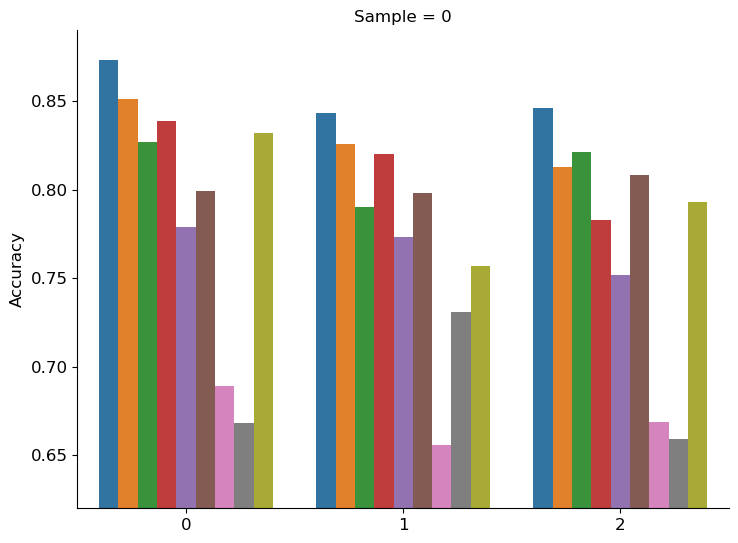

In [42]:
matplotlib.rcdefaults()

all_df = all_df.sort_index()
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(12, 5))

g = sns.catplot(x="Pair", y="Accuracy", hue='Kind', col="Sample", data=all_df, kind="bar", 
                aspect=1, legend=False, hue_order=['GEASO', 'Spateo', 'CAST', 'SLAT', 'Moscot', 'STAlign', 'SPACEL', 'PASTE2', 'PASTE'])

for ax in g.axes.flat:
    ax.set_ylabel("Accuracy")  # 设置y轴标签
    ax.tick_params(labelleft=True)  # 确保y轴标签可见

g.fig.set_size_inches(8, 6)
g.set_axis_labels("", "Accuracy")
g.set(ylim=(0.62, 0.89))

plt.savefig('GEASO_DLPFC_benchmark_all_2.pdf', bbox_inches='tight', dpi=600)
plt.show()

## Visualization of pairwise alignment results of partial overlap DLPFC slices

In [3]:
slice1 = sc.read_h5ad('D:/st_projects/paste2/sample_data/151674.h5ad')
slice2 = sc.read_h5ad('D:/st_projects/paste2/sample_data/151675.h5ad')
slice1, slice2

(AnnData object with n_obs × n_vars = 2877 × 12381
     obs: 'in_tissue', 'array_row', 'array_col', 'imagerow', 'imagecol', 'sum_umi', 'sum_gene', 'subject', 'position', 'replicate', 'discard', 'cell_count', 'layer_guess', 'layer_guess_reordered', 'layer_guess_reordered_short', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
     uns: 'layer_guess_reordered_colors'
     obsm: 'rgb', 'spatial',
 AnnData object with n_obs × n_vars = 2873 × 10629
     obs: 'in_tissue', 'array_row', 'array_col', 'imagerow', 'imagecol', 'sum_umi', 'sum_gene', 'subject', 'position', 'replicate', 'discard', 'cell_count', 'layer_guess', 'layer_guess_reordered', 'la

In [4]:
sc.pp.filter_cells(slice1, min_genes=10)
sc.pp.filter_genes(slice1, min_cells=3)
slice1.layers['counts'] = slice1.X.copy()
sc.pp.normalize_total(slice1)
sc.pp.log1p(slice1)
sc.pp.highly_variable_genes(slice1, n_top_genes=2000)

sc.pp.filter_cells(slice2, min_genes=10)
sc.pp.filter_genes(slice2, min_cells=3)
slice2.layers['counts'] = slice2.X.copy()
sc.pp.normalize_total(slice2)
sc.pp.log1p(slice2)
sc.pp.highly_variable_genes(slice2, n_top_genes=2000)

slice1.var_names_make_unique()
slice2.var_names_make_unique()

section_ids = ['slice1', 'slice2']
slice1.obs['batch'] = section_ids[0]
slice2.obs['batch'] = section_ids[1]

C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\libpysal\cg\voronoi.py:163: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  region_df['geometry'] = [Polygon(vertices[region]) for region in regions]
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\libpysal\cg\voronoi.py:166: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... 

Training on cuda, please wait...


Epoch: 199, Loss: -384.013 step time=0.058s: 100%|██████████| 200/200 [00:12<00:00, 16.43it/s]


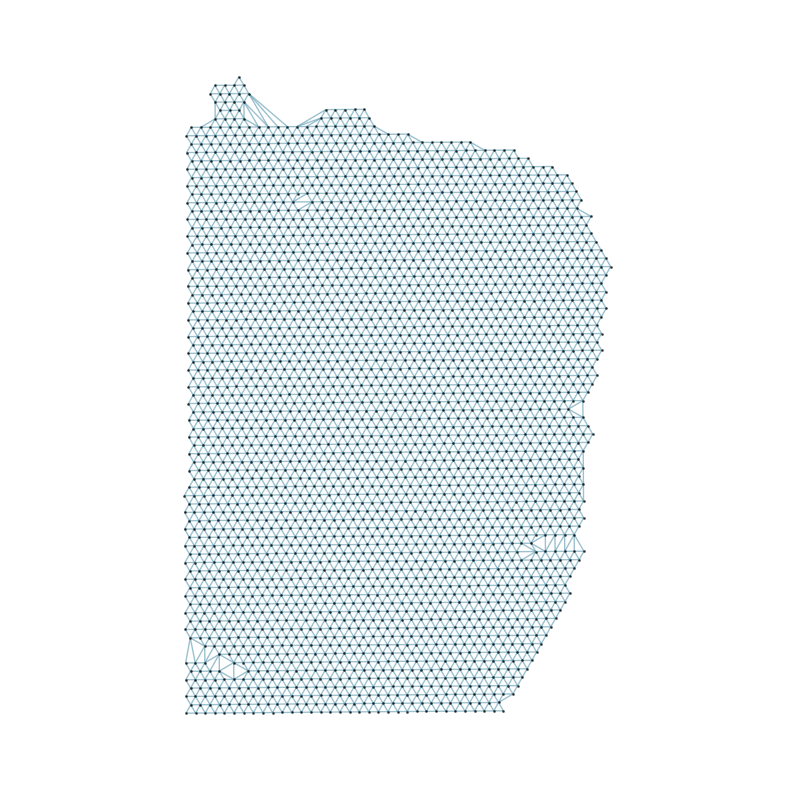

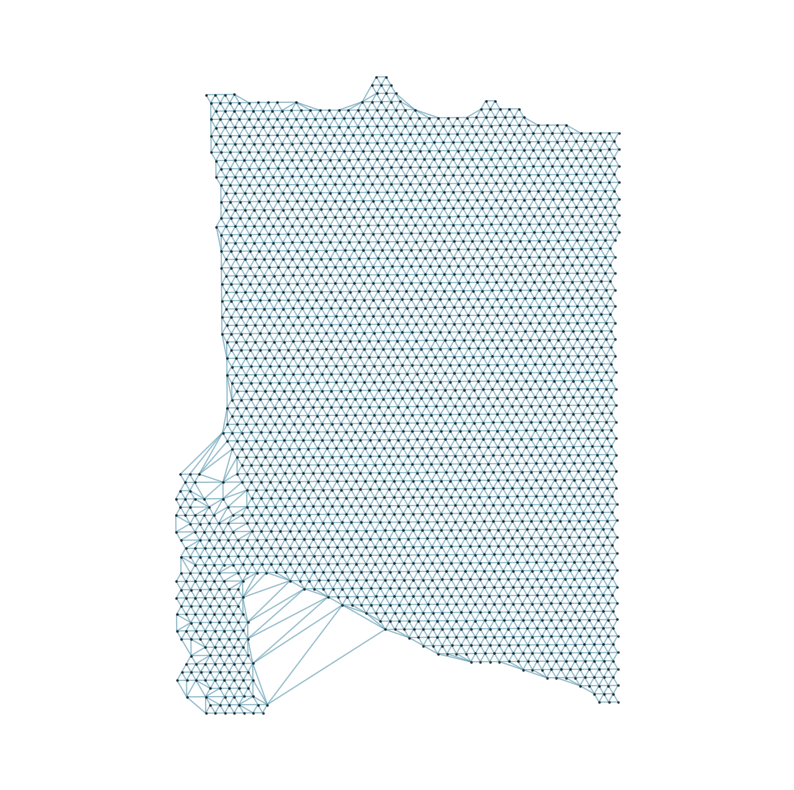

In [6]:
from GEASO.utils.utils import intersect, feature_extract
import torch

common_genes = intersect(slice1.var_names, slice2.var_names)
slice1 = slice1[:, common_genes]
slice2 = slice2[:, common_genes]

adata_list = [slice1, slice2]
emb_dict, loss_log, model = feature_extract(adata_list)
torch.cuda.empty_cache()

In [11]:
slice1.obsm['latent'] = emb_dict[section_ids[0]].cpu().numpy()
slice2.obsm['latent'] = emb_dict[section_ids[1]].cpu().numpy()

In [12]:
slice1.obsm['spatial'] = slice1.obsm['spatial'].astype('float')
slice2.obsm['spatial'] = slice2.obsm['spatial'].astype('float')

In [13]:
from GEASO.alignment.coarse_alignment import coarse_alignment

R, t, scale, P, spatial_scales, spatial_means, guided_source, guided_target, coarse_source, coarse_target = coarse_alignment(source=slice2, target=slice1, top_K=10, dis_metric='cos', use_latent=True, scale_c=False)

C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\P

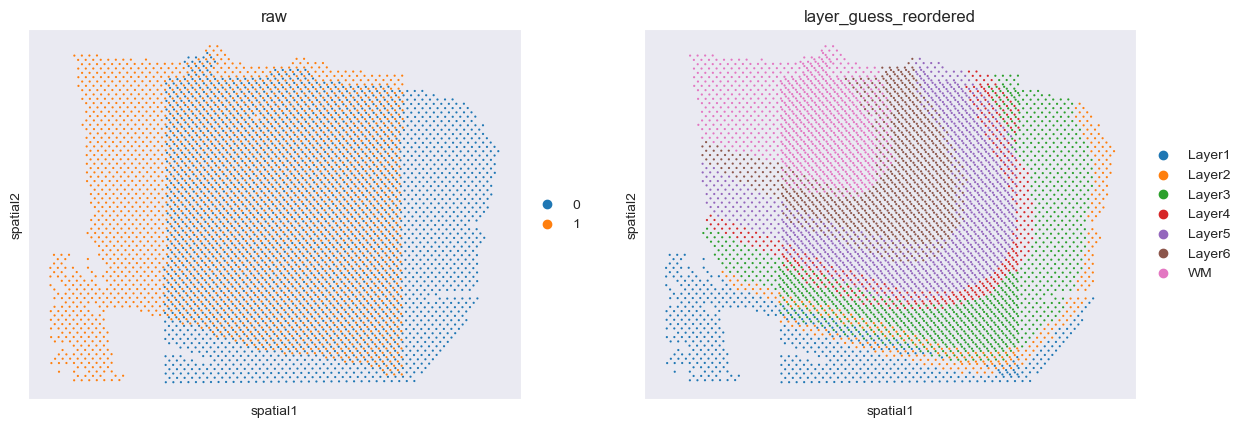

C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\P

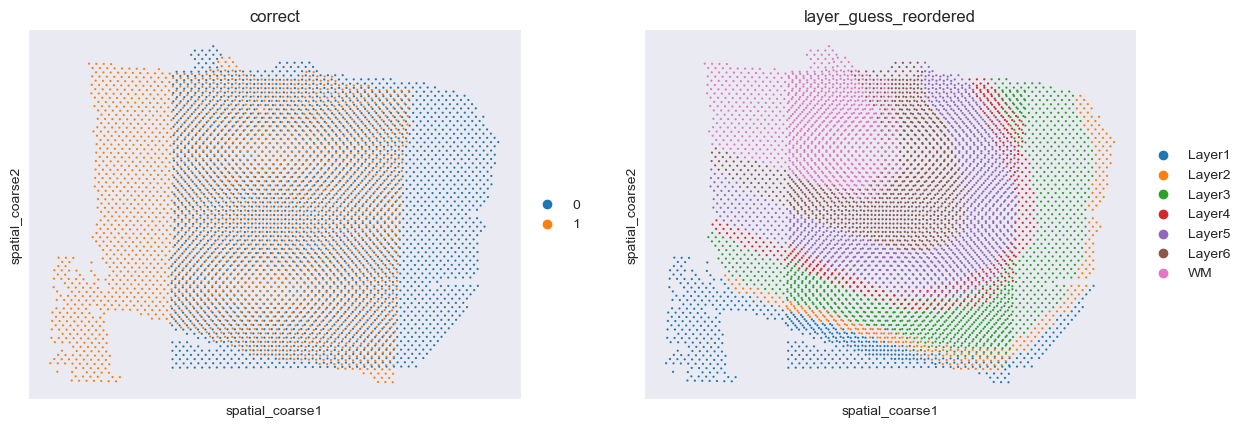

In [17]:
import anndata as ad

slice2.obsm['spatial_coarse'] = coarse_source.copy()
slice1.obsm['spatial_coarse'] = coarse_target.copy()

adata_cat = ad.concat([slice1, slice2], label='batch')
sc.pl.embedding(adata_cat, basis='spatial', color=['batch', 'layer_guess_reordered'], size=10, title='raw')
sc.pl.embedding(adata_cat, basis='spatial_coarse', color=['batch', 'layer_guess_reordered'], size=10, title='correct')

In [18]:
from GEASO.alignment.elastic_registration import ElasticRegistration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
register_model = ElasticRegistration(
    init_P=P,
    guided_source=guided_source,
    guided_target=guided_target,
    source_slice=slice2,
    target_slice=slice1,
    normalize_scales=spatial_scales,
    normalize_means=spatial_means,
    spatial_key='spatial_coarse',
    device=device,
    tau=0.3,
)

Local structure kernel constructed with shape: torch.Size([2873, 100])


Slice Alignment:   0%|          | 0/200 [00:00<?, ?it/s]D:\st_projects\GEASO\GEASO\alignment\elastic_registration.py:199: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  decay_val = torch.tensor(decay_val, device=self.SVI_decay.device, dtype=self.SVI_decay.dtype)
Slice Alignment: 100%|██████████| 200/200 [00:01<00:00, 132.70it/s]


C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


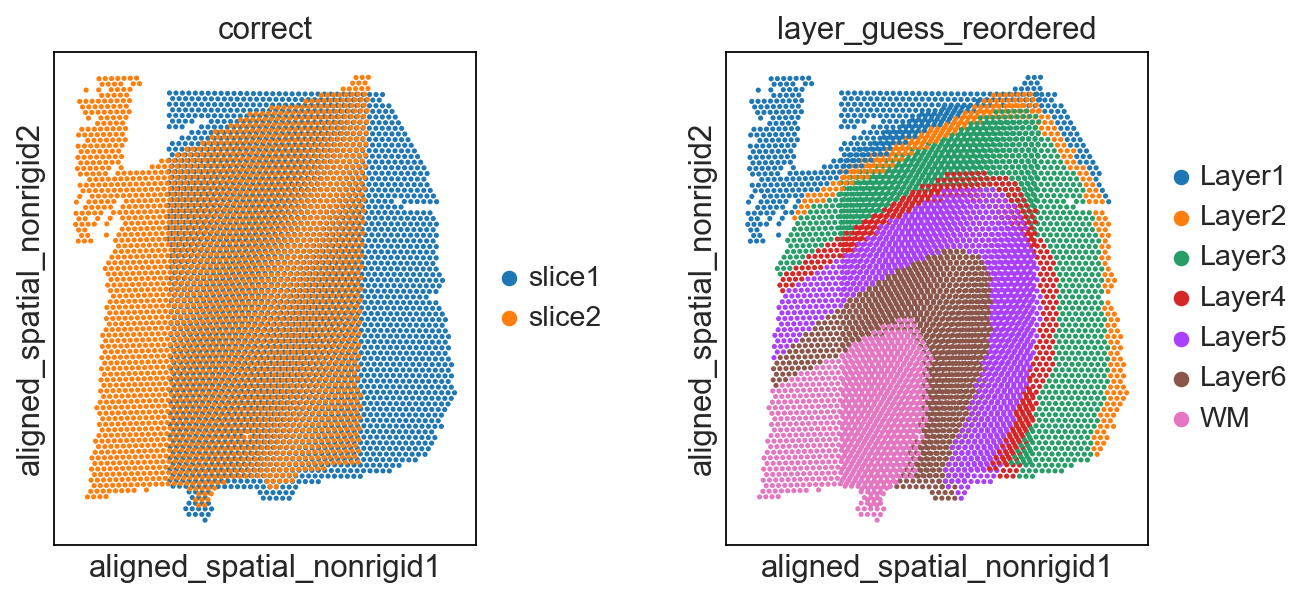

In [27]:
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=600, frameon=True, vector_friendly=True, color_map=None, format='pdf', facecolor=None, transparent=True, ipython_format='png2x')

slice1.obsm['aligned_spatial_nonrigid'] = slice1.obsm['spatial'].copy()

adata_cat = ad.concat([slice1, slice2], label='batch', keys=['slice1', 'slice2'])
sc.pl.spatial(adata_cat, basis='aligned_spatial_nonrigid', color=['batch', 'layer_guess_reordered'], spot_size=110, title='correct', save='_GEASO_DLPFC_Stitch')

## Calculate label consistency within overlapping region

In [28]:
# ensure index of spots within the overlapping region

from typing import List
from scipy.spatial import Delaunay
from itertools import chain
from shapely.geometry import LineString, Point, Polygon
from shapely.ops import polygonize, unary_union


def alpha_shape(points, alpha, only_outer=True) -> List:
    assert points.shape[0] > 3, "Need at least four points"

    def add_edge(edges, i, j):
        """
        Add an edge between the i-th and j-th points,
        if not in the list already
        """
        if (i, j) in edges or (j, i) in edges:
            # already added
            assert (j, i) in edges, "Can't go twice over same directed edge right?"
            if only_outer:
                # if both neighboring triangles are in shape, it's not a boundary edge
                edges.remove((j, i))
            return
        edges.add((i, j))

    tri = Delaunay(points)
    edges = set()
    circum_r_list = []
    for ia, ib, ic in tri.simplices:
        pa = points[ia]
        pb = points[ib]
        pc = points[ic]

        a = np.sqrt((pa[0] - pb[0]) ** 2 + (pa[1] - pb[1]) ** 2)
        b = np.sqrt((pb[0] - pc[0]) ** 2 + (pb[1] - pc[1]) ** 2)
        c = np.sqrt((pc[0] - pa[0]) ** 2 + (pc[1] - pa[1]) ** 2)
        s = (a + b + c) / 2.0
        area = np.sqrt(s * (s - a) * (s - b) * (s - c))
        circum_r = a * b * c / (4.0 * area)
        circum_r_list.append(circum_r)
        if circum_r < alpha:
            add_edge(edges, ia, ib)
            add_edge(edges, ib, ic)
            add_edge(edges, ic, ia)
    boundary = list(set(list(chain.from_iterable(list(edges)))))
    return boundary, edges, circum_r_list


def edges_to_polygon(points, edges):
    # 把每条边当成 LineString
    lines = [LineString([points[i], points[j]]) for i, j in edges]
    # 合并所有边并多边形化
    merged = unary_union(lines)
    polys = list(polygonize(merged))
    # 可能形成多个 Polygon，取最大的那个
    if len(polys) == 0:
        return None
    poly = max(polys, key=lambda p: p.area)
    return poly


def plot_alpha_shape(spatial_info, alpha=10):
    boundary, edges, _ = alpha_shape(spatial_info, alpha=alpha, only_outer=True)
    plt.scatter(spatial_info[:, 0], spatial_info[:, 1], s=0.5)
    for i, j in edges:
        plt.plot(spatial_info[[i, j], 0], spatial_info[[i, j], 1])
    plt.show()
    return boundary, edges


def mark_alpha_overlap(adata1, adata2, alpha1=100, alpha2=100, spatial_key='spatial'):
    pts1 = np.asarray(adata1.obsm[spatial_key])
    pts2 = np.asarray(adata2.obsm[spatial_key])

    _, edges1, _ = alpha_shape(pts1, alpha=alpha1, only_outer=True)
    _, edges2, _ = alpha_shape(pts2, alpha=alpha2, only_outer=True)

    poly1 = edges_to_polygon(pts1, edges1)
    poly2 = edges_to_polygon(pts2, edges2)
    if poly1 is None or poly2 is None:
        raise ValueError("Failed to construct polygon from edges!")

    overlap_poly = poly1.intersection(poly2)
    mask1 = [overlap_poly.contains(Point(x, y)) for x, y in pts1]
    adata1.obs['alpha_overlap'] = mask1
    mask2 = [overlap_poly.contains(Point(x, y)) for x, y in pts2]
    adata2.obs['alpha_overlap'] = mask2

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for ax, pts, mask, title in zip(
            axes,
            [pts1, pts2],
            [mask1, mask2],
            ['Slice1 Overlap', 'Slice2 Overlap']
    ):
        ax.scatter(pts[:, 0], pts[:, 1], s=0.5, c='lightgrey')
        ax.scatter(pts[mask, 0], pts[mask, 1], s=1.5, c='red')

    plt.tight_layout()
    plt.show()

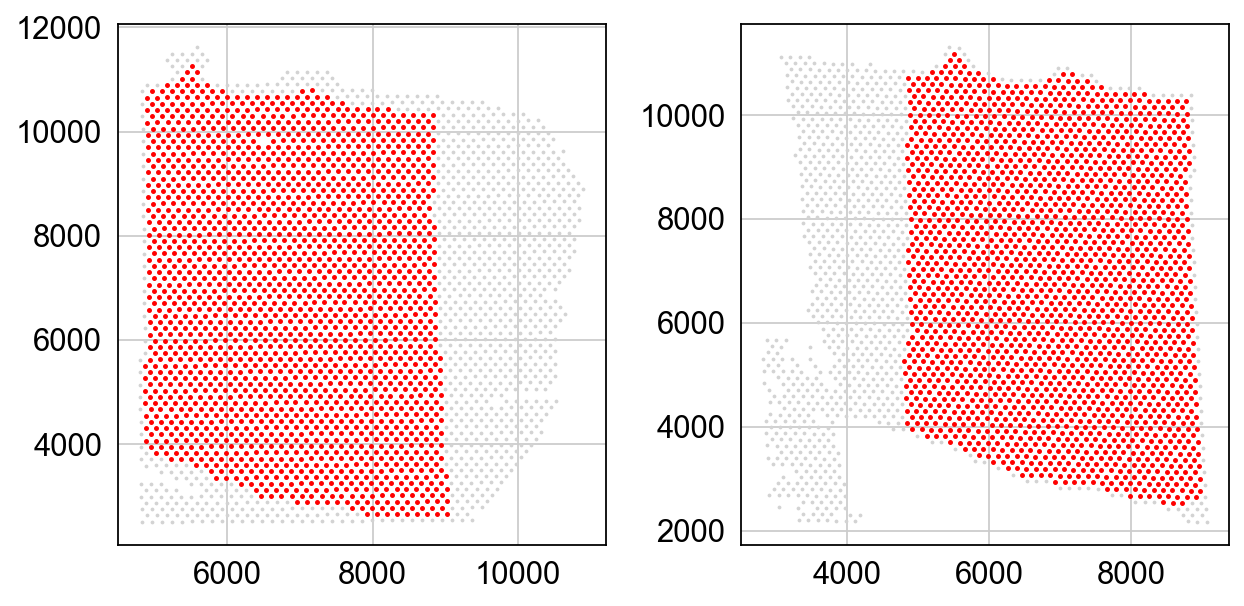

In [31]:
mark_alpha_overlap(slice1, slice2, alpha1=200, alpha2=200, spatial_key='aligned_spatial_nonrigid')
slice1_overlap = slice1[slice1.obs['alpha_overlap'] == True]
slice2_overlap = slice2[slice2.obs['alpha_overlap'] == True]

In [30]:
# get spot index of overlapping cells
mask = slice2.obs['alpha_overlap'].values.astype(bool)
idx  = np.flatnonzero(mask)
idx

array([   3,    5,    6, ..., 2868, 2869, 2872], dtype=int64)

In [32]:
import numpy as np
from sklearn.neighbors import BallTree

def build_mapping_matrix(coordsA, coordsB):
    nA = coordsA.shape[0]
    nB = coordsB.shape[0]

    treeB = BallTree(coordsB, leaf_size=15)
    dist, nn_idx = treeB.query(coordsA, k=1)  # dist.shape=(nA,1), nn_idx.shape=(nA,1)
    M = np.zeros((nA, nB), dtype=np.int32)
    for i in range(nA):
        j = nn_idx[i, 0]  # 最近邻的下标
        M[i, j] = 1

    return M

M = build_mapping_matrix(slice2.obsm['aligned_spatial_nonrigid'], slice1.obsm['aligned_spatial_nonrigid'])
M.shape

(2873, 2877)

In [33]:
count = 0
ref_raw_list = []
index = []
for i in idx:
    if np.sum(M[i] > 0):
        index.append(i)
        source_domain = slice2.obs['layer_guess_reordered'][i]
        max_align = M[i].argsort()[-1]
        target_domain = slice1.obs['layer_guess_reordered'].values[max_align]
        ref_raw_list.append(max_align)
        if source_domain == target_domain:
            count = count + 1

print(count / len(ref_raw_list), count, len(ref_raw_list))
index_harm = np.array(ref_raw_list)
index_harm

0.8331637843336724 1638 1966


C:\Users\wangyu\AppData\Local\Temp\ipykernel_33548\1826358130.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  source_domain = slice2.obs['layer_guess_reordered'][i]


array([1332, 2042, 2245, ...,  339,  748, 1060], dtype=int64)

## Visualize the alignment results within overlapping region

In [34]:
import pandas as pd

adata1_harm_df = pd.DataFrame({
    'index': range(slice1.shape[0]),
    'x': slice1.obsm['aligned_spatial_nonrigid'][:, 0],
    'y': slice1.obsm['aligned_spatial_nonrigid'][:, 1],
    'domain': slice1.obs['layer_guess_reordered'].astype('category'),
})

adata2_harm_df = pd.DataFrame({
    'index': range(slice2.shape[0]),
    'x': slice2.obsm['aligned_spatial_nonrigid'][:, 0],
    'y': slice2.obsm['aligned_spatial_nonrigid'][:, 1],
    'domain': slice2.obs['layer_guess_reordered'].astype('category'),
})

adata1_harm_df, adata2_harm_df

(                      index       x        y  domain
 AAACAAGTATCTCCCA-1.9      0  9733.0   8533.0  Layer3
 AAACAATCTACTAGCA-1.4      1  5713.0   2873.0  Layer1
 AAACAGAGCGACTCCT-1.8      2  9214.0   4217.0  Layer3
 AAACAGTGTTCCTGGG-1.6      3  5651.0  11258.0      WM
 AAACATTTCCCGGATT-1.9      4  9379.0   9848.0  Layer3
 ...                     ...     ...      ...     ...
 TTGTTCAGTGTGCTAC-1.9   2872  7140.0   5399.0  Layer5
 TTGTTGTGTGTCAAGA-1.9   2873  8029.0   6245.0  Layer5
 TTGTTTCACATCCAGG-1.9   2874  5595.0   9461.0      WM
 TTGTTTGTATTACACG-1.5   2875  5513.0  11257.0      WM
 TTGTTTGTGTAAATTC-1.9   2876  6261.0   3356.0  Layer1
 
 [2877 rows x 4 columns],
                        index            x             y  domain
 AAACAACGAATAGTTC-1.1       0  3985.366206   2192.611175  Layer1
 AAACACCAATAACTGC-1.10      1  3932.040034   9204.304534      WM
 AAACAGGGTCTATATT-1.10      2  3590.524897   7791.092742  Layer5
 AAACAGTGTTCCTGGG-1.7       3  5454.790522  10825.583099      WM

dataset1: 7 cell types; dataset2: 7 cell types; 
                    Total :7 celltypes; Overlap: 7 cell types 
                    Not overlap :[[]]
Subsampled 300 pairs from 1966


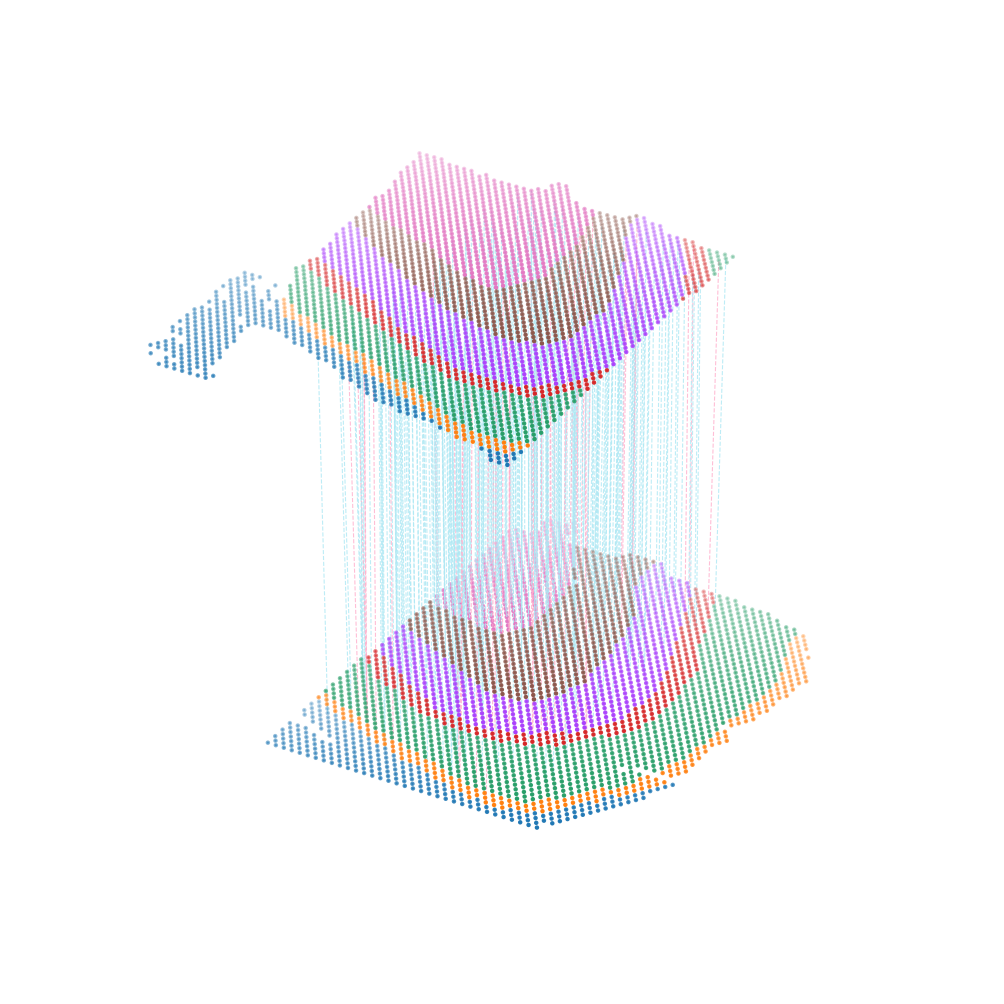

In [42]:
from GEASO.plot_utils.visualize import Build3D

matching_harm = np.array([index, index_harm])
multi_align = Build3D(adata1_harm_df, adata2_harm_df, matching_harm, meta='domain', scale_coordinate=False, subsample_size=300, exchange_xy=False)
multi_align.draw_3D(size=[16, 8], line_width=0.5, point_size=[1, 1], hide_axis=True, show_error=True, line_alpha=0.8)